# Stack Overflow Multilabel Classification

In [7]:
import matplotlib.pyplot as plt
import os
import re
import string
import tensorflow as tf

from pathlib import Path
from tensorflow.keras import layers, losses
from tensorflow.keras.layers.experimental.preprocessing import TextVectorization

# Multilabel Classification (Dataset: StackOverflow)

## Dataset Fetch

In [25]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/data/stack_overflow_16k.tar.gz"

In [26]:
datasets_dir = Path(os.path.abspath('')).parent.joinpath('datasets')
datasets_dir.mkdir(parents=True, exist_ok=True)

In [27]:
dataset = tf.keras.utils.get_file(fname="stack_overflow_16k.tar.gz", 
                                  origin=dataset_url,
                                  extract=True,
                                  cache_dir=datasets_dir,
                                  cache_subdir='stack_overflow_16k')

6053168/6053168 [==============================] - 0s 0us/step


In [28]:
so_dataset_dir = datasets_dir.joinpath("stack_overflow_16k")

In [29]:
so_train_dataset = so_dataset_dir.joinpath("train")
so_test_dataset = so_dataset_dir.joinpath("test")

In [30]:
os.listdir(so_train_dataset)

['python', 'java', 'csharp', 'javascript']

## Dataset Load

In [31]:
"""
Loads the Dataset in Batches/Lists of 32 entries each,
meaning that each iteration over the dataset will return 32 reviews
"""
batch_size = 32
seed = 42

### Loading Training Dataset

In [32]:
raw_train_ds = tf.keras.preprocessing.text_dataset_from_directory(
    directory=so_train_dataset,
    batch_size=batch_size,
    seed=seed,
    validation_split=0.2,
    subset='training'
)

Found 8000 files belonging to 4 classes.
Using 6400 files for training.


2024-01-27 02:55:24.550672: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Max
2024-01-27 02:55:24.550697: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2024-01-27 02:55:24.550705: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
2024-01-27 02:55:24.550740: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-01-27 02:55:24.550760: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


### Analysis of the Training Dataset

In [33]:
raw_train_ds.class_names

['csharp', 'java', 'javascript', 'python']

In [34]:
for t_corpus, t_label in raw_train_ds.take(1):
    for i in range(5):
        label  = t_label.numpy()[i]
        class_name = raw_train_ds.class_names[label]
        corpus = t_corpus.numpy()[i]
        print(f"Class Label: {label} ({class_name})")
        print(f"Review: {corpus}")
        print()

Class Label: 1 (java)
Review: b'"my tester is going to the wrong constructor i am new to programming so if i ask a question that can be easily fixed, please forgive me. my program has a tester class with a main. when i send that to my regularpolygon class, it sends it to the wrong constructor. i have two constructors. 1 without perameters..public regularpolygon().    {.       mynumsides = 5;.       mysidelength = 30;.    }//end default constructor...and my second, with perameters. ..public regularpolygon(int numsides, double sidelength).    {.        mynumsides = numsides;.        mysidelength = sidelength;.    }// end constructor...in my tester class i have these two lines:..regularpolygon shape = new regularpolygon(numsides, sidelength);.        shape.menu();...numsides and sidelength were declared and initialized earlier in the testing class...so what i want to happen, is the tester class sends numsides and sidelength to the second constructor and use it in that class. but it only u

### Loading Validation Dataset

In [35]:
raw_validation_ds = tf.keras.preprocessing.text_dataset_from_directory(
    directory=so_train_dataset,
    batch_size=batch_size,
    seed=seed,
    validation_split=0.2,
    subset='validation'
)

Found 8000 files belonging to 4 classes.
Using 1600 files for validation.


### Loading Test Dataset

In [36]:
raw_test_ds = tf.keras.preprocessing.text_dataset_from_directory(
    directory=so_test_dataset,
    batch_size=batch_size,
    seed=seed
)

Found 8000 files belonging to 4 classes.


## Dataset Preprocessing

### Standarization Function

In [37]:
def standardize_fn(input_data):
    lowercase_corpus = tf.strings.lower(input_data)
    newline_to_space = tf.strings.regex_replace(input=lowercase_corpus, 
                                    pattern='[\\n\\r\\t]+', 
                                    rewrite=' ')
    return tf.strings.regex_replace(input=newline_to_space, 
                                    pattern='[%s]+' % re.escape(string.punctuation), 
                                    rewrite=' ')

### Tokenization and Vectorization

In [38]:
"""Define the size of the vocabulary (the max number of words to be tokenized)"""
vocabulary_size = 10000
sequence_length = 500

vectorize_layer = TextVectorization(
    standardize=standardize_fn,
    max_tokens=vocabulary_size,
    output_mode='int',
    output_sequence_length=sequence_length    
)

def vectorize_text(text, label):
  text = tf.expand_dims(text, -1)
  return vectorize_layer(text), label

### Testing & Visualization

In [39]:
train_text = raw_train_ds.map(lambda text, class_label: text)

In [40]:
vectorize_layer.adapt(train_text)

2024-01-27 02:55:35.005388: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


In [41]:
corpus_batch, label_batch = next(iter(raw_train_ds))

In [42]:
post, label = corpus_batch[0], label_batch[0]

In [43]:
print("Pre-processing Post: ", post)
print("Post-processing Post: ", standardize_fn(post))
print("Class: ", raw_train_ds.class_names[label])

Pre-processing Post:  tf.Tensor(b'"set blank to quit on exception? i\'m using blank 3..i\'ve been looking around for an answer to this, but i haven\'t found it yet. basically, i\'m running several blank scripts into a game engine, and each script has its own entry point...i\'d rather not add try: except blocks through all of my code, so i was wondering if it\'s at all possible to tell blank to quit (or perhaps assign a custom function to that ""callback"") on finding its first error, regardless of where or what it found? ..currently, the game engine will continue after finding and hitting an error, making it more difficult than necessary to diagnose issues since running into one error may make a subsequent script not work (as it relies on variables that the error-ing script set, for example). any ideas? ..i know that i could redirect the console to a file to allow for easier scrolling, but just capturing the first error and stopping the game prematurely would be really useful...okay, a

In [44]:
print("Vectorized Post: ", vectorize_text(post, label))

Vectorized Post:  (<tf.Tensor: shape=(1, 500), dtype=int64, numpy=
array([[ 126,   17,    4, 1150,   54,  220,    2,   57,   58,   17,   53,
           2,  241,  308,  612,  711,   18,   48,  229,    4,   12,   31,
           2, 2105,   47,  289,   16, 1106,  745,    2,   57,  439, 1001,
          17, 1314,  146,    5,  303, 1719,   10,  167,  133,  140,  271,
         879,  791,  363,    2,  120, 1078,   36,   73,  153,  666, 2745,
         281,  100,   13,   28,   29,   64,    2,  165,  796,   14,   16,
          46,   81,  100,  278,    4,  597,   17,    4, 1150,   65, 2096,
         758,    5,  896,   32,    4,   21,  904,   54, 1322,  271,  125,
          75, 3253,   13,  171,   65,   62,   16,  289,  542,    3,  303,
        1719,  110,  673,  209, 1322,   10, 8550,   48,   75,  663,   16,
         250, 3184,  282, 1889,    4,    1, 1493,  628,  439,  146,   94,
          75,  642,  143,    5, 4533,  133,   36,  169,   51,   16,    1,
          54,  323,   21,    3,   75,    1,  

### Applying Vectorization to Training/Validation/Test Datasets

In [45]:
train_ds = raw_train_ds.map(vectorize_text)
validation_ds = raw_validation_ds.map(vectorize_text)
test_ds = raw_test_ds.map(vectorize_text)

### Caching Datasets to RAM

In [46]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds.cache().prefetch(buffer_size=AUTOTUNE)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 500), dtype=tf.int64, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

## Model Training

### Model Parametrization

In [47]:
embedding_dim = 128

In [48]:
model = tf.keras.Sequential([
    layers.Embedding(vocabulary_size+1, embedding_dim),
    layers.Dropout(0.2),
    layers.GlobalAveragePooling1D(),
    layers.Dropout(0.2),
    layers.Dense(4)
])

In [49]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 128)         1280128   
                                                                 
 dropout (Dropout)           (None, None, 128)         0         
                                                                 
 global_average_pooling1d (  (None, 128)               0         
 GlobalAveragePooling1D)                                         
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense (Dense)               (None, 4)                 516       
                                                                 
Total params: 1280644 (4.89 MB)
Trainable params: 1280644 (4.89 MB)
Non-trainable params: 0 (0.00 Byte)
__________________

In [50]:
model.compile(
    loss=losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

### Model Training

In [51]:
epochs = 10

In [52]:
history = model.fit(train_ds, 
                    validation_data=validation_ds, 
                    epochs=epochs)

Epoch 1/10
200/200 [==============================] - 20s 83ms/step - loss: 1.3532 - accuracy: 0.4064 - val_loss: 1.3022 - val_accuracy: 0.5013
Epoch 2/10
200/200 [==============================] - 16s 78ms/step - loss: 1.2113 - accuracy: 0.6137 - val_loss: 1.1178 - val_accuracy: 0.7056
Epoch 3/10
200/200 [==============================] - 16s 78ms/step - loss: 1.0164 - accuracy: 0.7327 - val_loss: 0.9485 - val_accuracy: 0.7056
Epoch 4/10
200/200 [==============================] - 15s 77ms/step - loss: 0.8496 - accuracy: 0.7831 - val_loss: 0.8080 - val_accuracy: 0.7837
Epoch 5/10
200/200 [==============================] - 15s 76ms/step - loss: 0.7232 - accuracy: 0.8234 - val_loss: 0.7147 - val_accuracy: 0.7975
Epoch 6/10
200/200 [==============================] - 15s 75ms/step - loss: 0.6297 - accuracy: 0.8380 - val_loss: 0.6406 - val_accuracy: 0.8250
Epoch 7/10
200/200 [==============================] - 15s 76ms/step - loss: 0.5588 - accuracy: 0.8545 - val_loss: 0.5890 - val_accuracy:

### Model Evaluation

In [53]:
loss, accuracy = model.evaluate(test_ds)

250/250 [==============================] - 1s 5ms/step - loss: 0.5007 - accuracy: 0.8375


In [54]:
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

Loss: 0.5007162094116211
Accuracy: 0.8374999761581421


In [55]:
history_dict = history.history
history_dict.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [56]:
bin_acc = history_dict['accuracy']
validation_acc = history_dict['val_accuracy']

In [57]:
loss = history_dict['loss']
validation_loss = history_dict['val_loss']

In [58]:
epochs = range(1, len(bin_acc) + 1)

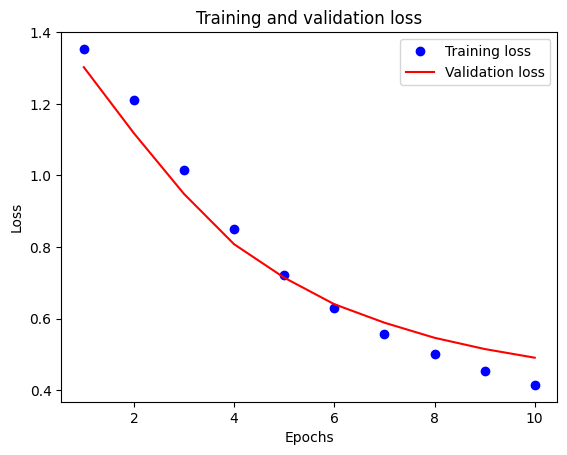

In [59]:
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, validation_loss, 'red', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

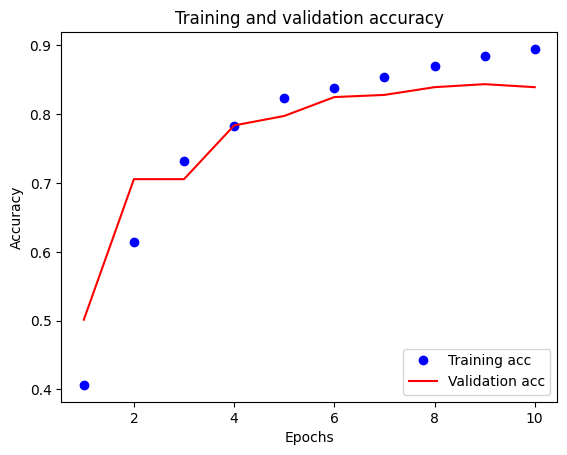

In [60]:
plt.plot(epochs, bin_acc, 'bo', label='Training acc')
plt.plot(epochs, validation_acc, 'red', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

plt.show()

## Model Export

In [61]:
export_model = tf.keras.Sequential([
    vectorize_layer,
    model,
    layers.Activation('sigmoid')
])

In [62]:
export_model.compile(
    loss=losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer='adam',
    metrics=['accuracy']
)

In [63]:
loss, accuracy = export_model.evaluate(raw_test_ds)

  8/250 [..............................] - ETA: 1s - loss: 0.5521 - accuracy: 0.8086 

/opt/homebrew/Caskroom/miniconda/base/envs/fastapi/lib/python3.11/site-packages/keras/src/backend.py:5727: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


250/250 [==============================] - 2s 6ms/step - loss: 0.5007 - accuracy: 0.8375


## Model Inference

In [64]:
samples = [
"""
No PHP, podemos converter uma quebra de linha para um através da função nl2br. 
E no JavaScript? Como posso fazer isso de maneira segura?Decidi fazer a pergunta porque não sei 
se um simples replace(\n") cabe para todos os casos de quebra de linha.
""",


"""
Quando eu declaro funcionario como Pessoa no main(), para onde "vai" o valor do atributo salario, 
já que a classe Pessoa não tem esse atributo?

public abstract class Pessoa {
    private String nome;
    private Long cpf;

    public Pessoa(String nome, Long cpf) {
        this.nome = nome;
        this.cpf = cpf;
    }
}

public class Funcionario extends Pessoa {
    private float salario;
    public Funcionario(String nome, Long cpf, float salario) {
        super(nome, cpf);
        this.salario = salario;
    }
}

public class Principal {
    public static void main(String[] args) {
        Pessoa funcionario = new Funcionario("Fulano", 123L, 1000);
    }

}
""",


"""
Como usar uma função de variável várias vezes sem precisar criar outra variável? Como por exemplo sortear um número
import random
n = random.randint(1, 6)
print('O valor sorteado foi {}'.format(n))
if nd !=n:
    print('Não foi dessa vez')
if nd ==n:
    print('Parabéns! Você está com sorte')
start1 = str(input('Deseja continuar? '))
if start1 =='Sim':
    nd1 = int(input('Qual valor você deseja? De 1 até 6? '))
else: exit()
n1 = random.randint(1, 6)
print('O valor sorteado foi {}'.format(n1))
if nd1 ==n1:
    print('Parabéns! Você está com sorte')
else: print('Não foi dessa vez!')
""",


"""
 Que tipo de dado usar para armazenar data de falecimento num cadastro (DateTime ou string)?
 Tenho um cadastro de pessoas onde preciso armazenar as datas de nascimento (DateBirth) e falecimento (DateDeath). 
 Sabendo que o tipo DateTime em C# não pode ser vazio e seu valor inicial padrão é 01/01/0001 00:00:00, o que não faz sentido para o preenchimento de um campo que trata de uma data de falecimento de uma pessoa, que solução vocês aplicariam? Definiriam mesmo assim a propriedade como do tipo DateTime e fariam algum tipo de tratamento depois? Definiriam como do tipo string? Ou que outra solução sugeririam?

  public class Person
  {
      public string Name { get; set; }
      public string Gender { get; set; }
      public DateTime DateBirth { get; set; }

      // Definir a propriedade como DateTime há um valor inicial pré-definido: 01/01/0001
      // public DateTime DateDeath { get; set; }
      
      // Ou definir a propriedade como string, iniciando-a com valor vazio,
      // mas sem os recursos de validação do tipo DateTime.
      // public string DateDeath { get; set; }
  }   
"""
]

In [65]:
"""
The classes represented in the array, from left to right, are: 
C#, Java, JavaScript, Python
"""
export_model.predict(samples, verbose=1)

1/1 [==============================] - 0s 103ms/step


array([[0.59884715, 0.4594396 , 0.40315494, 0.4732413 ],
       [0.9216405 , 0.96416557, 0.02522262, 0.08257471],
       [0.25828785, 0.5150545 , 0.10501684, 0.9496461 ],
       [0.97832   , 0.7559278 , 0.01147326, 0.28351653]], dtype=float32)

In [66]:
raw_train_ds.class_names

['csharp', 'java', 'javascript', 'python']